# Data Cleaning Round 1

In [2]:
#import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor

from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Import data from last step
df = pd.read_csv('../data/PATH_N_NAME_OF THE FILE.csv')


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Remove duplicates

In [ ]:
#print df columns
print (df.shape)
print (df.columns)

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

## ID missing values

In [ ]:
# Check for null values
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

## Dealing with Outliers

In [8]:
for col in df.select_dtypes(include='number'):   # only numeric columns
    thresh = df[col].quantile(0.95)
    df[col] = df[col].clip(upper=thresh)

In [10]:
#get all columns with null values

columns_with_nulls = []
for column in df.columns:
    if df.loc[:, column].isnull().any():
        columns_with_nulls.append(column)

print(columns_with_nulls)

['LotFrontage', 'Alley', 'MasVnrType', 'MasVnrArea', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Electrical', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature']


#### Data Visualization

In [11]:
def plot_boxplot(df, column_name):
    """
    Plots a box plot for a specific column in a DataFrame.

    Parameters:
    df (pd.DataFrame): The input DataFrame.
    column_name (str): The name of the column to plot.

    Returns:
    None
    """
    if column_name not in df.columns:
        print(f"Column '{column_name}' not found in DataFrame.")
        return
    
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=df[column_name])
    plt.title(f'Box Plot of {column_name}')
    plt.xlabel(column_name)
    plt.grid(True)
    plt.show()

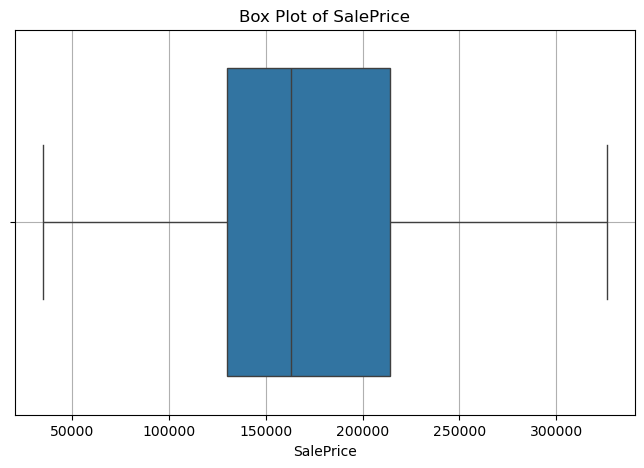

In [12]:
#checking for negatives and outliers
plot_boxplot(df,'SalePrice')

### Train-Test Split
To prevent data leakage, we will do our train/test split now, to hold out one part of the dataset completely away as the holdout set.

In [13]:
df = df.drop(columns=columns_with_nulls)

#drop the Id column
df = df.drop(['Id','Utilities'],axis=1)

df.columns

Index(['MSSubClass', 'MSZoning', 'LotArea', 'Street', 'LotShape',
       'LandContour', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1',
       'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea',
       'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr',
       'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional',
       'Fireplaces', 'GarageCars', 'GarageArea', 'PavedDrive', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SaleType', 'SaleCondition',
       'SalePrice'],
      dtype='object')

In [14]:
# splitting data into features and targets 
x = df.drop(columns=['SalePrice','Condition2','Street'])
y = df.loc[:, 'SalePrice']

##### remove the following cols from the x_train and x_test
remove_cols = ['BsmtFinSF1','BsmtHalfBath','BedroomAbvGr','BsmtFullBath','2ndFlrSF','EnclosedPorch','3SsnPorch']
x = x.drop(remove_cols,axis=1)

# Removing 20% of data as test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

#### Plot correlation matrix for only numerical columns

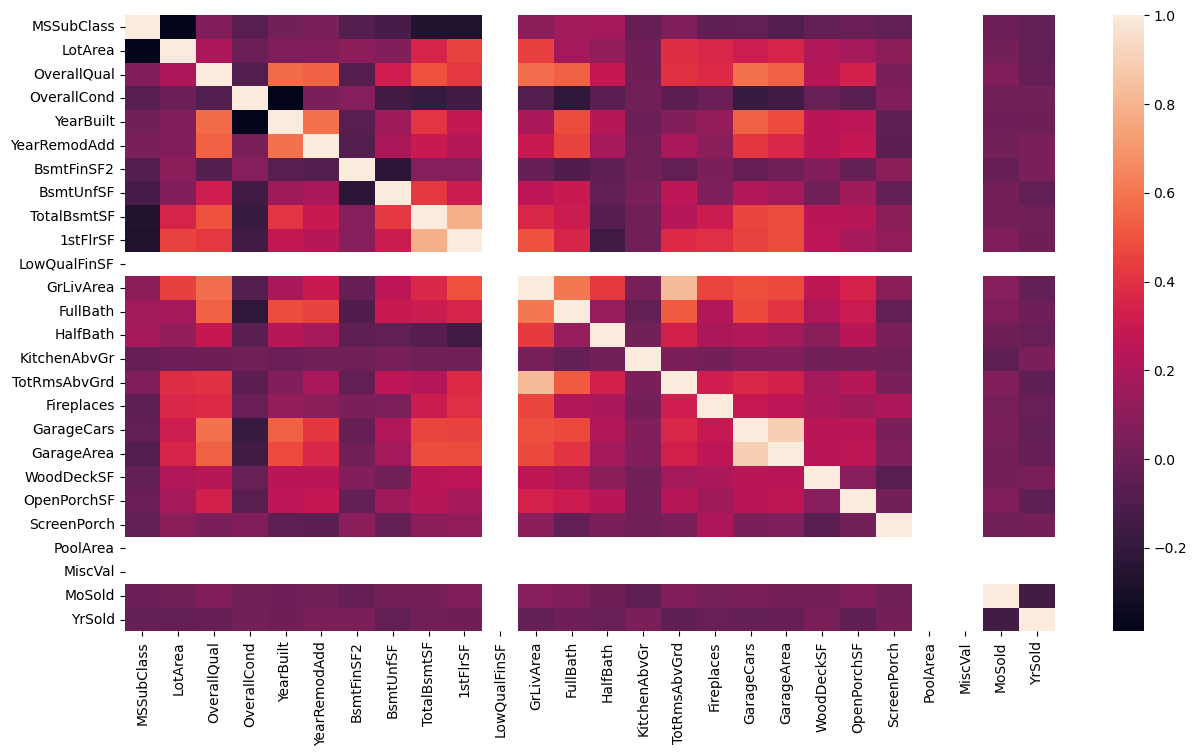

In [15]:
plt.figure(figsize=(15,8))
sns.heatmap(x_train.select_dtypes(include=["number"]).corr())


plt.show()

In [16]:
#remove highly correlated columns

high_corr = ['1stFlrSF','YearRemodAdd','MoSold','ScreenPorch','OpenPorchSF','HalfBath']

x_train = x_train.drop(high_corr,axis=1)

In [17]:
x_train.head()

,MSSubClass,MSZoning,LotArea,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,Condition1,BldgType,...,Fireplaces,GarageCars,GarageArea,PavedDrive,WoodDeckSF,PoolArea,MiscVal,YrSold,SaleType,SaleCondition
254,20,RL,8400.0,Reg,Lvl,Inside,Gtl,NAmes,Norm,1Fam,...,0,1,294.0,Y,250,0,0,2010,WD,Normal
1066,60,RL,7837.0,IR1,Lvl,Inside,Gtl,Gilbert,Norm,1Fam,...,1,2,380.0,Y,0,0,0,2009,WD,Normal
638,30,RL,8777.0,Reg,Lvl,Inside,Gtl,Edwards,Feedr,1Fam,...,0,0,0.0,P,328,0,0,2008,WD,Normal
799,50,RL,7200.0,Reg,Lvl,Corner,Gtl,SWISU,Feedr,1Fam,...,2,1,240.0,Y,0,0,0,2007,WD,Normal
380,50,RL,5000.0,Reg,Lvl,Inside,Gtl,SWISU,Norm,1Fam,...,1,1,308.0,Y,0,0,0,2010,WD,Normal


### Dealing With Categorical Columns

In [18]:
# Select categorical columns with relatively low cardinality (convenient but arbitrary)
categorical_cols = [name for name in x_train.columns if x_train[name].nunique() < 3 and x_train[name].dtype == "object"]

# Select numerical columns
numerical_cols = [cname for cname in x_train.columns if x_train[cname].dtype in ['int64', 'float64']]

# Keep selected columns only
my_cols = categorical_cols + numerical_cols

x_train = x_train[my_cols].copy()
x_test = x_test[my_cols].copy()

print('My dataframe now has {} columns.'.format(len(my_cols)))

My dataframe now has 21 columns.


In [19]:
print(my_cols)

['CentralAir', 'MSSubClass', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'LowQualFinSF', 'GrLivArea', 'FullBath', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'PoolArea', 'MiscVal', 'YrSold']


In [20]:
print(f'My Total data sum is {x_train.shape[0] + x_test.shape[0]}')

My Total data sum is 1460


In [21]:
#print categorical columns

categorical_cols

['CentralAir']

#### Encode categorical columns

In [22]:
from sklearn.impute import SimpleImputer
import pandas as pd

# Imputers
num_imputer = SimpleImputer(strategy='mean')
cat_imputer = SimpleImputer(strategy='most_frequent')

# Fit and transform numerical columns
imputed_num_train = pd.DataFrame(num_imputer.fit_transform(x_train[numerical_cols]),columns=numerical_cols)
imputed_num_test = pd.DataFrame(num_imputer.transform(x_test[numerical_cols]),columns=numerical_cols)

# Fit and transform categorical columns
imputed_cat_train = pd.DataFrame(cat_imputer.fit_transform(x_train[categorical_cols]),columns=categorical_cols)
imputed_cat_test = pd.DataFrame(cat_imputer.transform(x_test[categorical_cols]),columns=categorical_cols)

# Combine numerical and categorical back together
imputed_x_train = pd.concat([imputed_num_train, imputed_cat_train], axis=1)
imputed_x_test = pd.concat([imputed_num_test, imputed_cat_test], axis=1)

In [23]:
from sklearn.preprocessing import OrdinalEncoder

# Make copy to avoid changing original data 
label_x_train = imputed_x_train.copy()
label_x_test = imputed_x_test.copy()

# Apply ordinal encoder to each column with categorical data
ordinal_encoder = OrdinalEncoder()
label_x_train[categorical_cols] = ordinal_encoder.fit_transform(imputed_x_train[categorical_cols])
label_x_test[categorical_cols] = ordinal_encoder.transform(imputed_x_test[categorical_cols])

## ML Model

### Linear Regression

In [24]:
label_x_train.columns

Index(['MSSubClass', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'LowQualFinSF', 'GrLivArea',
       'FullBath', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars',
       'GarageArea', 'WoodDeckSF', 'PoolArea', 'MiscVal', 'YrSold',
       'CentralAir'],
      dtype='object')

In [25]:
#baseline model
lr_model = LinearRegression()

# Preprocessing of training data, fit model 
lr_model.fit(label_x_train, y_train)

# Preprocessing of test data, get predictions
preds = lr_model.predict(label_x_test)

# Evaluate the model
score = mean_absolute_error(y_test, preds)
print('MAE for Linear Regression', score)

MAE for Linear Regression 17437.953969430917


In [26]:
#evaluate the model for r2
from sklearn.metrics import r2_score

r2_test = r2_score(y_test, preds)
print('R2 Score for Linear Regression', r2_test)

R2 Score for Linear Regression 0.8876764934257177


In [27]:
r2_train = r2_score(y_train, lr_model.predict(label_x_train))
print('R2 Score for Linear Regression', r2_train)

R2 Score for Linear Regression 0.863489166531839
